In [1]:
from core import AnalysisConfig, Reference, ObsType
from utils import Analyzer, ResultsManager
from utils.workdirectory import WorkDirectory
from pathlib import Path
PROJECTDIR = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/')

Welcome to JupyROOT 6.30/02


In [33]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mplhep
mplhep.style.use("CMS")

class CMSPlotStyle:
    def __init__(self, figsize=(20, 12), label_fs=26, tick_fs=26, cms_fs=26, xlabel=None, ylabel=None, ytick_list=None):
        self.figsize = figsize
        self.label_fs = label_fs
        self.tick_fs = tick_fs
        self.cms_fs = cms_fs
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.ytick_list = ytick_list
    
    def setup_figure(self, figsize=None):
        figsize = figsize or self.figsize
        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')
        
        # Configure spines (exactly like original)
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
        
        # Configure tick parameters (exactly like original)
        ax.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                       labelsize=self.tick_fs, top=True, right=True, bottom=True, left=True, color='black')
        ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                       top=True, right=True, bottom=True, left=True, color='black')
        
        # Configure grid (exactly like original)
        ax.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
        ax.grid(False, axis='x')
        
        return fig, ax
    
    def add_cms_text(self, ax):
        """Add CMS text using mplhep (exactly like original _cms_text)"""
        mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=self.cms_fs, loc=0)
        ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=self.cms_fs,
                horizontalalignment='right', verticalalignment='bottom')

In [42]:
def plot_brazilian(df: pd.DataFrame, outfile, plot_style=None, label_column='label'):
    """
    Create a CMS-style horizontal bar plot showing confidence limits
    
    Parameters:
    - df: DataFrame with columns ['label', 'median', 'down1', 'up1', 'down2', 'up2']
    - outfile: Output filename for the plot
    - plot_style: CMSPlotStyle object (optional, uses default if not provided)
    - label_column: Name of column containing labels (default 'label')
    """
    # Use default style if none provided
    if plot_style is None:
        plot_style = CMSPlotStyle()
    
    # Setup figure using the style class
    fig, ax = plot_style.setup_figure()
    
    if df.empty:
        print("No data to plot!")
        return
    
    labels = df[label_column].tolist()
    N = len(labels)
    
    # CONTROL BAR THICKNESS AND SPACING
    bar_height = 0.5  # thinner bars
    bar_spacing = 0   # zero spacing

    for i, (_, row) in enumerate(df.iterrows()):
        label = row[label_column]
        median = row["mu"]
        # Calculate confidence intervals from your data structure
        low1 = median - row["sigma1_min"]
        high1 = row["sigma1_max"] - median
        low2 = median - row["sigma2_min"]
        high2 = row["sigma2_max"] - median

        y_center = i * (bar_height + bar_spacing)

        # ±2σ band
        ax.barh(y_center, low2 + high2, left=median - low2, height=bar_height, 
                color="gold", zorder=1, edgecolor='none')
        # ±1σ band
        ax.barh(y_center, low1 + high1, left=median - low1, height=bar_height, 
                color="forestgreen", zorder=2, edgecolor='none')
        # Median line
        ax.vlines(median, y_center - bar_height / 2, y_center + bar_height / 2, 
                  color="black", linestyle="--", linewidth=1.2, zorder=3)

        # Text labels
        text_label_x_pos = -0.25
        ax.text(text_label_x_pos, y_center + 0.07, f"{label}", ha="left", fontsize=plot_style.tick_fs, 
                weight='bold', transform=ax.get_yaxis_transform())
        ax.text(text_label_x_pos, y_center - 0.07, f"Expected {median:.2f}", ha="left", 
                fontsize=plot_style.tick_fs, transform=ax.get_yaxis_transform())

    # Vertical theory line
    y_top_center = (N - 1) * (bar_height + bar_spacing)
    y_top_edge = y_top_center + bar_height / 2
    ax.vlines(x=1.0, ymin=-bar_height / 2, ymax=y_top_edge, color="red", 
              linestyle="-", linewidth=1.5, zorder=4)
    
    # Axis styling
    ax.set_xlim(left=0)
    
    # Set axis labels
    xlabel = plot_style.xlabel if plot_style.xlabel else r"Upper 95% CLs limit on $\sigma(\mathrm{pp} \rightarrow \mathrm{HH}) / \sigma_\mathrm{SM}$"
    ax.set_xlabel(xlabel, fontsize=plot_style.label_fs)
    
    # Configure x-axis ticks
    ax.tick_params(axis="x", labelsize=plot_style.tick_fs, zorder=5)
    # Force the ticks and spines to be drawn on top
    ax.set_axisbelow(False)

    # Add CMS text using the style class
    plot_style.add_cms_text(ax)

    # ============================================
    # Legend =====================================
    # ============================================
    theory_legend = [plt.Line2D([0], [0], color="red", linestyle="-", label="Theory prediction")]

    from matplotlib.patches import Rectangle
    from matplotlib.legend_handler import HandlerBase

    # Custom handler to draw a patch with a dashed line through the center
    class PatchWithLineHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
            patch_color = orig_handle[0]
            line_style = orig_handle[1]
            # Full-size patch
            patch = Rectangle([xdescent, ydescent], width, height, facecolor=patch_color, 
                            edgecolor="none", transform=trans, zorder=1)
            # Dashed line through center
            line = plt.Line2D([xdescent, xdescent + width], [ydescent + height / 2] * 2, 
                            linestyle=line_style, color="black", linewidth=1.5, transform=trans, zorder=2)
            return [patch, line]

    # Define legend handles as (color, linestyle)
    green_legend = ("forestgreen", "--")
    yellow_legend = ("gold", "--")

    # Legend items
    other_legend = [
        green_legend,
        yellow_legend,
        plt.Line2D([0], [0], color="black", linestyle="--", label="Median expected")
    ]

    # Create legends with consistent font size from style class
    legend_fontsize = plot_style.tick_fs  # Use tick font size for legends
    leg_y_pos = 0.90
    fig.legend(handles=theory_legend, loc="upper right", bbox_to_anchor=(0.71, leg_y_pos), 
               fontsize=legend_fontsize, frameon=False)
    fig.legend(handles=other_legend, labels=[r"$\pm 1\sigma$ expected", r"$\pm 2\sigma$ expected", "Median expected"],
               loc="upper right", bbox_to_anchor=(0.95, leg_y_pos), fontsize=legend_fontsize, frameon=False, 
               handler_map={tuple: PatchWithLineHandler()})

    # Set y-axis limits precisely to avoid spacing
    total_height = N * (bar_height + bar_spacing)
    top_margin = 0.6
    yticks = []
    for i in range(N):
        y_center = i * (bar_height + bar_spacing)
        yticks.extend([y_center - bar_height / 2, y_center + bar_height / 2])
    ax.set_yticks(yticks)
    
    # Remove minor ticks and customize major ticks
    ax.tick_params(axis="y", which="minor", left=False, right=False)
    ax.tick_params(axis="y", which="major", length=12, width=2, labelsize=0, left=True, right=True)
    
    ax.set_ylim(-bar_height / 2, total_height - bar_spacing - bar_height / 2 + top_margin)
    ax.grid(False, axis='y')

    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style limits plot saved to {outfile}")
    plt.show()

In [13]:
file_path = PROJECTDIR / 'crtd_final' / 'LLR_from_vars' / 'fits_new' / 'summary_results.txt'
df_llrs_from_vars = ResultsManager.load_summary_files(file_path)
df_llrs_from_vars = df_llrs_from_vars.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_vars = df_llrs_from_vars.dropna()

df_llrs_from_1D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_1D']
df_llrs_from_2D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_2D']
df_llrs_from_3D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_3D']

In [19]:
best_llrs_from_vars = df_llrs_from_vars.loc[df_llrs_from_vars.groupby('n_variables')['mu'].idxmin()]
best_llrs_from_vars

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
27,jj_l_dR_llr,423.2,304.1,590.3,229.0,789.0,llr_from_1D,1
0,jj_l_dR_vs_bjets_pt_bb_llr,288.2,206.9,404.3,154.8,542.6,llr_from_2D,2
61,bjets_dR_vs_blnu_bl_mInv_vs_bjets_mbb_llr,524.5,375.0,739.8,280.7,1004.0,llr_from_3D,3


In [21]:
subprojectdir = PROJECTDIR / 'crtd_final'
crtd_dirs = [d for d in subprojectdir.iterdir() if d.is_dir() and 'LLR_cmb' in d.name]
file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in crtd_dirs]
df_llrs_fact = ResultsManager.load_summary_files(file_paths)
df_llrs_fact = df_llrs_fact.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_fact

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_...,110.9,75.77,163.5,54.35,229.3,llr_factorized,8
1,jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_m...,111.2,75.22,164.0,53.23,231.4,llr_factorized,9
2,jj_l_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_...,112.6,78.47,163.4,57.63,225.6,llr_factorized,7
3,jj_l_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_...,112.9,77.73,165.2,56.25,231.3,llr_factorized,6
4,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_...,112.9,76.32,167.3,54.01,236.7,llr_factorized,10
...,...,...,...,...,...,...,...,...
32747,trijet_pt_rat_x_bjets_dPhi_llr,684.2,491.60,954.3,370.20,1275.0,llr_factorized,2
32748,trijet_bijet_dPhi_x_trijet_pt_rat_x_trijet_bij...,693.8,498.50,967.5,375.30,1293.0,llr_factorized,3
32749,trijet_bijet_dPhi_x_trijet_pt_rat_llr,698.9,502.20,974.7,378.10,1303.0,llr_factorized,2
32750,trijet_pt_rat_x_trijet_bijet_dR_llr,715.5,514.10,997.8,387.10,1334.0,llr_factorized,2


In [47]:
best_llr_factorized = df_llrs_fact.iloc[0:1]  # Use iloc[0:1] to keep it as DataFrame
best_llrs = pd.concat([best_llrs_from_vars, best_llr_factorized], ignore_index=True)
best_llrs['original_obs_name'] = best_llrs['obs_name'].copy()
best_llrs.loc[0, 'obs_name'] = 'Univariate LLR'
best_llrs.loc[1, 'obs_name'] = 'Bivariate LLR'
best_llrs.loc[2, 'obs_name'] = 'Trivariate LLR'
best_llrs.loc[3, 'obs_name'] = 'Factorized LLR'
best_llrs

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables,original_obs_name
0,Univariate LLR,423.2,304.10,590.3,229.00,789.0,llr_from_1D,1,jj_l_dR_llr
1,Bivariate LLR,288.2,206.90,404.3,154.80,542.6,llr_from_2D,2,jj_l_dR_vs_bjets_pt_bb_llr
2,Trivariate LLR,524.5,375.00,739.8,280.70,1004.0,llr_from_3D,3,bjets_dR_vs_blnu_bl_mInv_vs_bjets_mbb_llr
3,Factorized LLR,110.9,75.77,163.5,54.35,229.3,llr_factorized,8,jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_...


CMS-style limits plot saved to llr_study/UL_brazilian_llrs.pdf


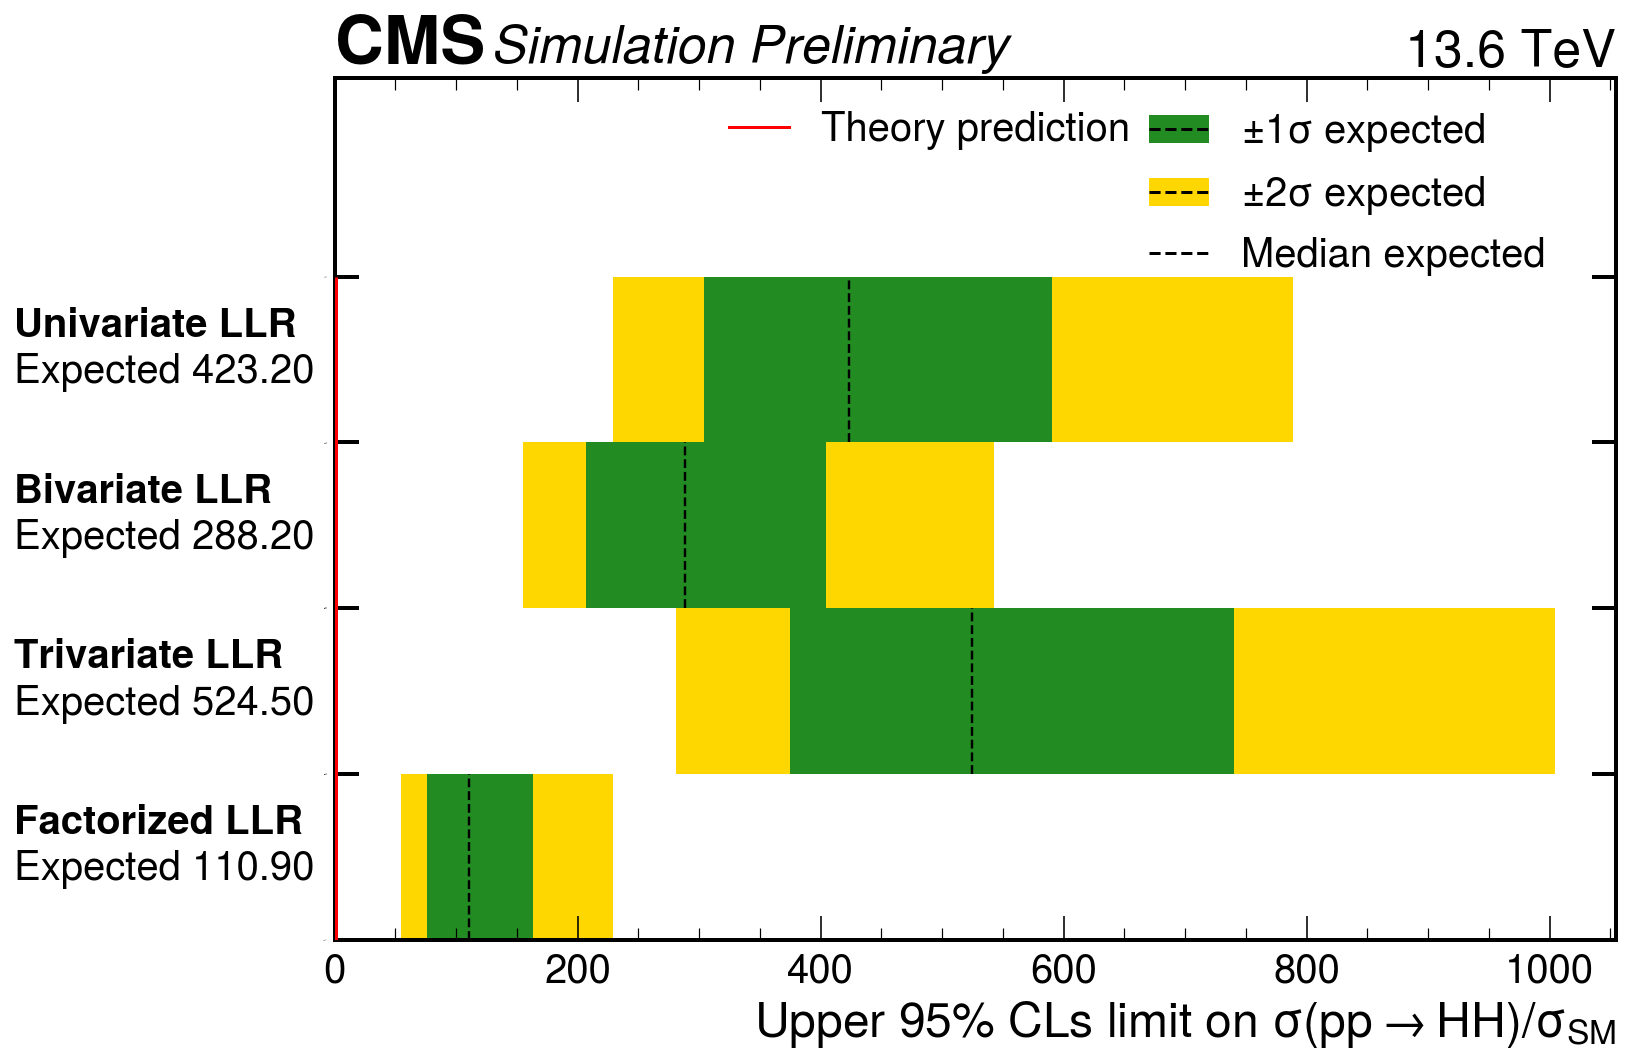

In [48]:
plot_style = CMSPlotStyle(
    figsize=(12,8), 
    label_fs=24,
    tick_fs=20
)
best_llrs = best_llrs.iloc[::-1]
plot_brazilian(best_llrs, 
                outfile=Path('llr_study') / 'UL_brazilian_llrs.pdf',
                plot_style = plot_style,
                label_column='obs_name')